# Decision Tree Classifier

## Importing Required Libraries
Importing libraries for data manipulation, visualization, and machine learning operations.

In [22]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import category_encoders as ce

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier ,plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix ,classification_report
from sklearn.model_selection import GridSearchCV

## Loading the Dataset
Loading the `car_evaluation.csv` dataset and exploring its structure, info, and summary statistics.

In [3]:
df = pd.read_csv(r'F:\HUAWEL_AI\GitHub\Data_CSV\car_evaluation.csv')

print("Dataset shape:", df.shape)

print("\nDataFrame Columns",df.columns)

print("\nColumn information:",df.info())

print("\nMissing values (Null):",df.isnull().sum())

print("\nBasic statistics:",df.describe())

print("\nDuplicated:",df.duplicated().sum())

Dataset shape: (1727, 7)

DataFrame Columns Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'low', 'unacc'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB

Column information: None

Missing values (Null): vhigh      0
vhigh.1    0
2          0
2.1        0
small      0
low        0
unacc      0
dtype: int64

Basic statistics:        vhigh vhigh.1     2   2.1 small   low  unacc
count   1727    1727  1727  1727  1727  1727   1727
unique     4       4     4     3     3     3      4
top     high    high     3     4   med   med  unacc
freq     432  

## Renaming Columns
Renaming the columns of the dataframe to standard names indicating what the features represent.

In [4]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names

## Splitting Features and Target
Separating the independent features (`X`) from the target dependent variable (`y`).

In [5]:
X = df.drop(['class'], axis=1)

y = df['class']

## Train-Test Split
Splitting the data into training and testing sets (80% training data, 20% test data).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Encoding Categorical Variables
Using `OrdinalEncoder` to convert the categorical features into numerically encoded variables.

In [7]:
cols_to_encode = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

encoder = OrdinalEncoder()

X_train[cols_to_encode] = encoder.fit_transform(X_train[cols_to_encode])

X_test[cols_to_encode] = encoder.transform(X_test[cols_to_encode])

X_train = X_train.astype(int)
X_test = X_test.astype(int)

print("Encoded X_train:")
print(X_train)
print("\nEncoded X_test:")
print(X_test)


Encoded X_train:
      buying  maint  doors  persons  lug_boot  safety
107        3      0      0        0         2       1
900        2      3      1        1         2       2
1708       1      1      3        0         0       0
705        0      2      2        0         1       2
678        0      2      1        0         1       2
...      ...    ...    ...      ...       ...     ...
1130       2      2      1        2         0       1
1294       2      1      3        2         0       0
860        0      1      3        2         0       1
1459       1      0      2        0         2       0
1126       2      2      1        2         2       0

[1381 rows x 6 columns]

Encoded X_test:
      buying  maint  doors  persons  lug_boot  safety
599        0      0      2        0         0       1
932        2      3      2        1         0       1
628        0      0      3        0         0       0
1497       1      0      3        1         1       2
1262       2      1    

## Initializing Decision Tree (Gini Index)
Training a Decision Tree classifier using `gini` index as the splitting criterion.

In [8]:

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

clf_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Making Predictions (Gini Index)
Predicting the test set results using the Gini Index model.

In [9]:
y_pred_gini = clf_gini.predict(X_test)

## Model Evaluation (Gini Index)
Calculating the accuracy score for the trained Gini Index model.

In [10]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.7832


## Visualizing the Decision Tree (Gini Index)
Plotting the structure of the Gini Index Decision Tree.

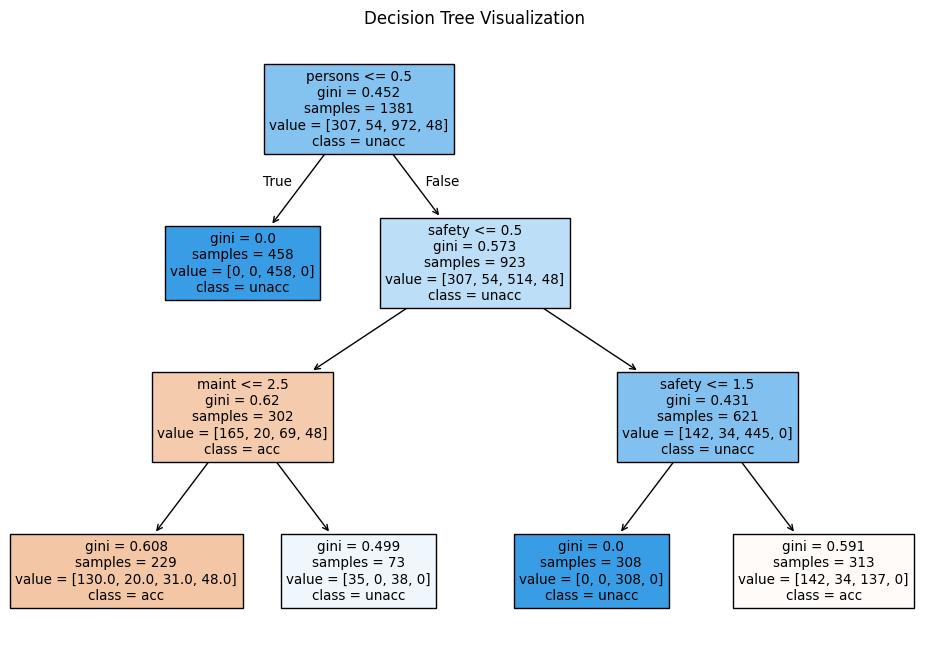

In [11]:
plt.figure(figsize=(12, 8))
plot_tree(clf_gini, filled=True, 
            feature_names=list(X_train.columns), 
            class_names=list(clf_gini.classes_.astype(str)))
plt.title("Decision Tree Visualization")
plt.show()

## Classification Report (Gini Index)
Displaying more detailed metrics including precision, recall, and f1-score.

In [12]:
print(classification_report(y_test, y_pred_gini))

              precision    recall  f1-score   support

         acc       0.51      0.86      0.64        77
        good       0.00      0.00      0.00        15
       unacc       0.95      0.86      0.91       237
       vgood       0.00      0.00      0.00        17

    accuracy                           0.78       346
   macro avg       0.36      0.43      0.39       346
weighted avg       0.76      0.78      0.76       346



c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Initializing Decision Tree (Entropy)
Training a Decision Tree classifier using `entropy` as the splitting criterion.

In [13]:
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

clf_en.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Making Predictions (Entropy)
Predicting the test set outcomes using the Entropy model.

In [14]:
y_pred_en = clf_en.predict(X_test)

## Model Evaluation (Entropy)
Checking the testing accuracy score for the entropy model.

In [15]:
print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.7890


## Training Set Predictions (Entropy)
Predicting on the training data to evaluate if overfitting occurred.

In [16]:
y_pred_train_en = clf_en.predict(X_train)

y_pred_train_en

array(['unacc', 'acc', 'unacc', ..., 'unacc', 'unacc', 'acc'],
      shape=(1381,), dtype=object)

## Training Set Accuracy (Entropy)
Checking the training accuracy score for the entropy model.

In [17]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.7777


## Initializing Decision Tree (Gini Index)
Training a Decision Tree classifier using `gini` index as the splitting criterion.

In [18]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                            cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best accuracy score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 126 candidates, totalling 630 fits
Best hyperparameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best accuracy score: 0.9355595667870036


## Visualizing the Best Decision Tree
Plotting the optimal, tuned Decision Tree.

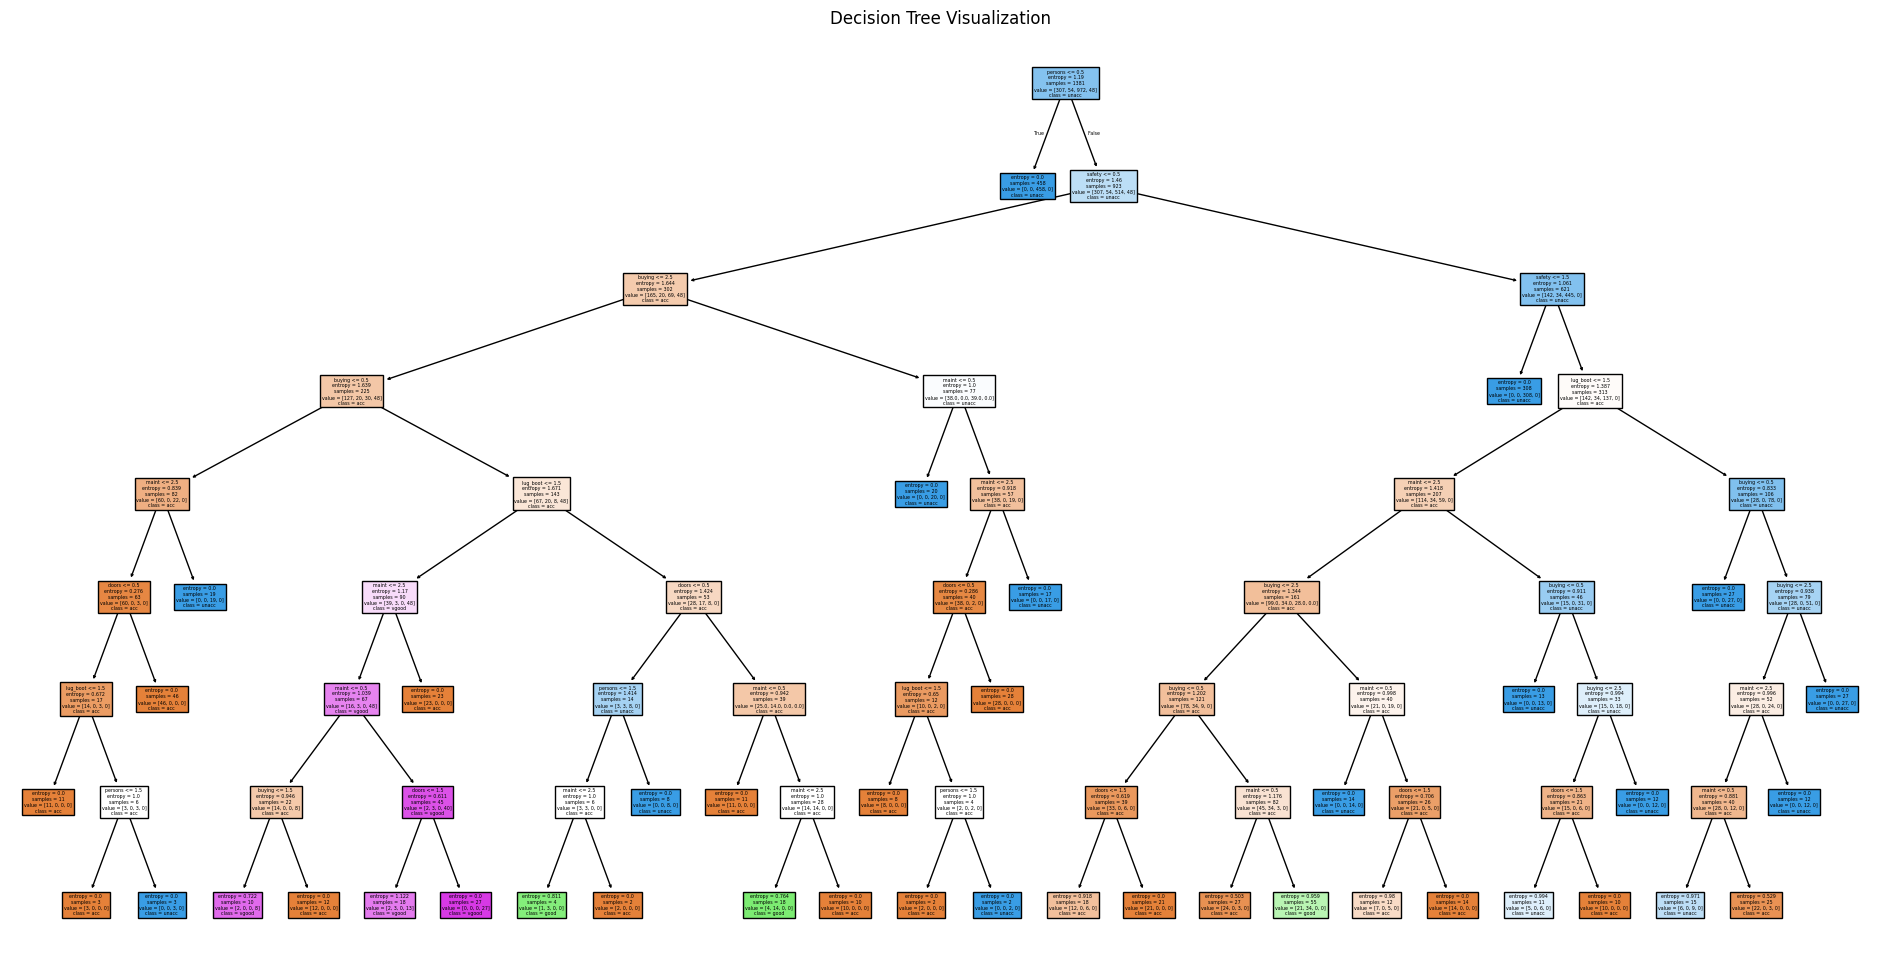

In [19]:
plt.figure(figsize=(24, 12)) 
plot_tree(best_model, filled=True, 
            feature_names=list(X_train.columns), 
            class_names=list(best_model.classes_.astype(str)))
plt.title("Decision Tree Visualization")
plt.show()

## Predicting using the Best Model
Making predictions with the optimized Hyperparameters.

In [20]:
y_pred = best_model.predict(X_test)


test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

train_accuracy = best_model.score(X_train, y_train)
print("Train Accuracy:", train_accuracy)

Test Accuracy: 0.9219653179190751
Train Accuracy: 0.9558291093410572


## Final Classification Report
Reviewing the performance metrics of the fine-tuned model.

In [21]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

         acc     0.9242    0.7922    0.8531        77
        good     0.5294    0.6000    0.5625        15
       unacc     0.9748    0.9789    0.9768       237
       vgood     0.6800    1.0000    0.8095        17

    accuracy                         0.9220       346
   macro avg     0.7771    0.8428    0.8005       346
weighted avg     0.9297    0.9220    0.9231       346

